# Relationships between demand, generation and climate modes

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr
from scipy.stats import anderson_ksamp, ks_2samp
import geopandas

import warnings

import string
letters = list(string.ascii_lowercase)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/c

In [2]:
%cd /g/data/w42/dr6273/work/seasonal_energy/
import functions as fn

/g/data/w42/dr6273/work/seasonal_energy


In [3]:
%load_ext autoreload
%autoreload 2

# Load data

#### Climate drivers

- 3 monthly mean for oceanic indices

In [4]:
def roll_3month(ds):
    """
    3 monthly mean
    """
    return ds.rolling(time=3).mean()

In [5]:
drivers_fp = "/g/data/w42/dr6273/work/data/"

In [6]:
nino34 = xr.open_zarr(
    drivers_fp + "hadisst/climate_modes/hadisst_nino34_1940-2023.zarr",
    consolidated=True
)["nino34_detrended"]

In [7]:
nino34 = roll_3month(nino34).compute()

In [8]:
dmi = xr.open_zarr(
    drivers_fp + "hadisst/climate_modes/hadisst_dmi_1940-2023.zarr",
    consolidated=True
)["dmi_detrended"]

In [9]:
dmi = roll_3month(dmi).compute()

In [10]:
sam = xr.open_zarr(
    drivers_fp + "era5/climate_modes/era5_sam_1940-2023.zarr",
    consolidated=True
)["sam_detrended"].compute()

Can't floor timestamps to the beginning of the month, so hack it and set Nino34 and DMI time to that of SAM

In [11]:
nino34["time"] = sam["time"]

In [12]:
dmi["time"] = sam["time"]

#### Generation and demand

In [15]:
def detrended_plus_mean(
    var_name, name, convert="TWh", time_slice=slice("1941", None)
):
    """
    Load detrended data and add mean of original data

    var_name: str, variable name in dataset
    name: str, filename
    convert: str, 'GWh' or 'TWh' divides by 1e3 or 1e6, respectively
    time_slice: slice, times to select.
    """
    monthly = fn.load_monthly(name, convert, time_slice)
    orig_mean = monthly[var_name].mean("time")
    return monthly[var_name + "_detrended"] + orig_mean

In [16]:
demand_current = detrended_plus_mean(
    "demand", "demand_state_training2010-16_extrapolate1940-2023"
)

In [17]:
demand_SC30 = detrended_plus_mean(
    "demand", "demand_state_step_change_2029-30_training2010-16_extrapolate1940-2023"
)

In [18]:
demand_SC40 = detrended_plus_mean(
    "demand", "demand_state_step_change_2039-40_training2010-16_extrapolate1940-2023"
)

In [19]:
demand_SC50 = detrended_plus_mean(
    "demand", "demand_state_step_change_2049-50_training2010-16_extrapolate1940-2023"
)

In [20]:
shortfall_current = detrended_plus_mean(
    "shortfall", "shortfall_REZ_current_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [21]:
shortfall_SC30 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_step_change_2029-30_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [22]:
shortfall_SC40 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_step_change_2039-40_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [23]:
shortfall_SC50 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_step_change_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

More scenarios based on 2050 but with additional generation from Green Energy Exports scenario (except offshore wind, which is from DCCEEW).

In [24]:
shortfall_Q1 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_artificial_Q1_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [25]:
shortfall_Q2 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_artificial_Q2_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [26]:
shortfall_Q5 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_artificial_Q5_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [27]:
shortfall_Q6 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_artificial_Q6_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [28]:
shortfall_N10 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_artificial_N10_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [29]:
shortfall_T3 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_artificial_T3_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [30]:
shortfall_V5 = detrended_plus_mean(
    "shortfall", "shortfall_REZ_artificial_V5_2049-50_state_van_der_Wiel_training2010-16_extrapolate1940-2023"
)

In [31]:
wind_current = detrended_plus_mean(
    "power", "wind_power_REZ_current_state_van_der_Wiel_era5_monthly_1940-2023"
)

In [32]:
wind_SC30 = detrended_plus_mean(
    "power", "wind_power_REZ_step_change_2029-30_state_van_der_Wiel_era5_monthly_1940-2023"
)

In [33]:
wind_SC40 = detrended_plus_mean(
    "power", "wind_power_REZ_step_change_2039-40_state_van_der_Wiel_era5_monthly_1940-2023"
)

In [34]:
wind_SC50 = detrended_plus_mean(
    "power", "wind_power_REZ_step_change_2049-50_state_van_der_Wiel_era5_monthly_1940-2023"
)

In [35]:
solar_current = detrended_plus_mean(
    "power", "solar_power_REZ_current_state_van_der_Wiel_era5_monthly_1940-2023"
)

In [36]:
solar_SC30 = detrended_plus_mean(
    "power", "solar_power_REZ_step_change_2029-30_state_van_der_Wiel_era5_monthly_1940-2023"
)

In [37]:
solar_SC40 = detrended_plus_mean(
    "power", "solar_power_REZ_step_change_2039-40_state_van_der_Wiel_era5_monthly_1940-2023"
)

In [38]:
solar_SC50 = detrended_plus_mean(
    "power", "solar_power_REZ_step_change_2049-50_state_van_der_Wiel_era5_monthly_1940-2023"
)

### Interannual variability

In [39]:
def anomalise(ds, groupby="time.month"):
    """
    Return values with mean subtracted.
    
    ds: dataset with 'time' dimension
    groupby: None, or str in form e.g. 'time.month'
    """
    if groupby is not None:
        return ds.groupby(groupby).apply(lambda x: x - x.mean("time"))
    else:
        return ds - ds.mean("time")

In [40]:
def plot_ts(ax, ds_list, ds_names, region, month, colors, plot_std, ylabel, yticks, legend_loc, filename=None):
    """
    Plot anomalised time series for a given month(s)
    
    ax: axes
    ds_list: list of datasets
    ds_names: list of string, describing items in ds_list
    region: str, region to select
    month: int or list of int between 1 and 12, default is None
    colors: list of str, colours for lines
    plot_std: bool, whether to plot standard deviation of ds_list[0]
    ylabel: str, ylabel
    yticks: list or array, y-axis ticks
    legend_loc: str or tuple
    filename: str, path to save figure to. Default is None.
    """
    data = [
        anomalise(
            fn.sel_month(ds.sel(region=region), month),
            "time.month"
        ).resample(time="1YS").mean() for ds in ds_list
    ]
    
    # Standard deviations for each scenario
    stds = [ds.std("time").values for ds in data]
    
    for i, (ds, name, color) in enumerate(zip(data, ds_names, colors)):
        ds.plot(ax=ax, color="dimgray", lw=1.5, alpha=1)
        ds.plot(ax=ax, color=color, label=name, alpha=1, zorder=2)
        ax.axhline(0, color="k", lw=0.5, zorder=1)


    if plot_std:
        std_alpha=0.3
        for i in range(len(stds)):
            
            if i == 0:
                ax.fill_between(
                    x=ds.time, y1=stds[i], y2=-1 * stds[i], color=colors[i], alpha=std_alpha, lw=0, zorder=0
                )
            else:
                ax.fill_between(
                    x=ds.time, y1=stds[i], y2=stds[i-1], color=colors[i], alpha=std_alpha, lw=0, zorder=0
                )
                ax.fill_between(
                    x=ds.time, y1=-1 * stds[i-1], y2=-1 * stds[i], color=colors[i], alpha=std_alpha, lw=0, zorder=0
                )
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_title("")
    # ax.legend(ncols=4, loc=legend_loc, frameon=False)
    ax.legend(ncols=4, loc=(0.12, 0), frameon=False)
    
    ax.set_yticks(yticks)

In [41]:
def annual_means(ds_list):
    """
    Annual means of ds_list for region
    """
    return [ds.mean("time") for ds in ds_list]

In [43]:
COLORS = ["#d7191c", "#fdae61", "#abd9e9", "#2c7bb6"][::1]

In [45]:
# Get REZ shapefiles
rez_gpd = geopandas.read_file(
    "/g/data/w42/dr6273/work/projects/Aus_energy/data/resource_coded_Indicative_REZ_boundaries_2024_GIS_data.shp",
    # driver="ESRI shapefile"
)

In [46]:
# Need to convert Cartopy CRS to be compatible with GeoPandas
# https://geopandas.org/en/stable/gallery/cartopy_convert.html
# Define the CartoPy CRS object.
crs = ccrs.PlateCarree()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
rez_gpd = rez_gpd.to_crs(crs_proj4)

In [47]:
# Annual mean monthly consumption
ann_dem = annual_means([demand_current, demand_SC30, demand_SC40, demand_SC50])
ann_wind = annual_means([wind_current, wind_SC30, wind_SC40, wind_SC50])
ann_solar = annual_means([solar_current, solar_SC30, solar_SC40, solar_SC50])

In [48]:
r = "NEM"
p_dem = [ds.sel(region=r).values for ds in ann_dem]
p_wind = [ds.sel(region=r).values for ds in ann_wind]
p_solar = [ds.sel(region=r).values for ds in ann_solar]

In [49]:
p_dem

[array(15.33328131),
 array(17.99994798),
 array(24.24994798),
 array(28.33328131)]

In [50]:
pc_p_wind = [str(int(np.round(p_wind[i] / p_dem[i] * 100, 0)))+"%" for i in range(4)]
pc_p_solar = [str(int(np.round(p_solar[i] / p_dem[i] * 100, 0)))+"%" for i in range(4)]

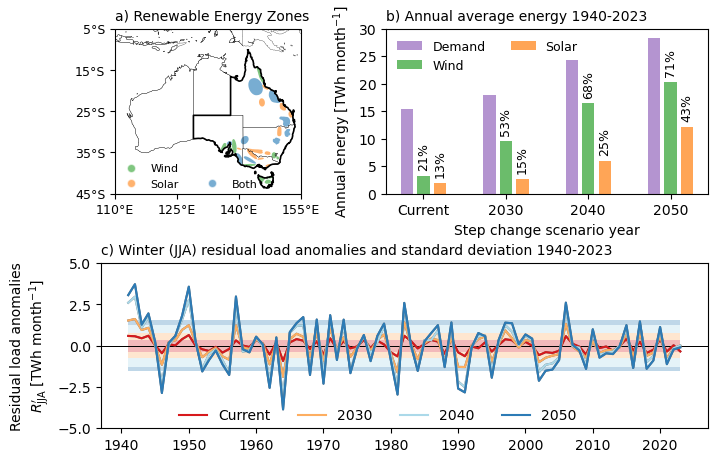

In [67]:
fig = plt.figure(figsize=(7,4.5), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[0.4, 0.6], height_ratios=[0.5, 0.5])
ax1 = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,:])

for a in [ax1]:
    a.coastlines(lw=.2, rasterized=True)
    a.set_extent([110, 155.001, -5, -40.1])
    a.add_feature(
        cartopy.feature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces',
            scale='50m'
        ),
        facecolor='none',
        edgecolor='k',
        lw=.2,
        rasterized=True
    )

# -------------------------------------------------------------------
# Thick outline of QLD + NSW + VIC + SA + TAS
# -------------------------------------------------------------------
from cartopy.io import shapereader
from shapely.ops import unary_union

wanted = {
    'Queensland',
    'New South Wales',
    'Australian Capital Territory',
    'Victoria',
    'South Australia',
    'Tasmania'
}

shp = shapereader.natural_earth(
    resolution='50m',
    category='cultural',
    name='admin_1_states_provinces'
)

reader = shapereader.Reader(shp)

geoms = [
    rec.geometry
    for rec in reader.records()
    if rec.attributes["admin"] == "Australia"
    and rec.attributes["name"] in wanted
]

# Merge the five polygons
merged = unary_union(geoms)

# Draw only the exterior boundary
ax1.add_geometries(
    [merged.boundary],
    crs=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='k',
    linewidth=1.2
)
    
ax1.set_xticks(np.arange(110, 156, 15), crs=ccrs.PlateCarree())
ax1.set_yticks(np.arange(-5, -45.001, -10), crs=ccrs.PlateCarree())
ax1.tick_params(axis='x', labelsize=9)
ax1.tick_params(axis='y', labelsize=9)
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
    
alpha=0.6
for i in range(len(rez_gpd)):
    d = rez_gpd.iloc[i:i+1]
    code = d.iloc[0]['code_2023']
    # if code not in [4, 9]:
    #     d.plot(ax=ax1, alpha=alpha, color="tab:purple", rasterized=True)
    if (code == 1) | (code == 4):
        d.plot(ax=ax1, alpha=alpha, color="tab:green", label='Wind', rasterized=True)
    elif code == 2:
        d.plot(ax=ax1, alpha=alpha, color="tab:orange", label='Solar', rasterized=True)
    elif code == 3:
        d.plot(ax=ax1, alpha=alpha, color="tab:blue", label='Wind and solar', rasterized=True)
    elif code == 5:
        pass
    else:
        raise ValueError('Incorrect code')
        
# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Wind',
            markerfacecolor="tab:green", markersize=6, alpha=alpha),
    Line2D([0], [0], marker='o', color='w', label='Solar',
            markerfacecolor="tab:orange", markersize=6, alpha=alpha),
    Line2D([0], [0], marker='o', color='w', label='',
            markerfacecolor="w", markersize=6, alpha=alpha),
    Line2D([0], [0], marker='o', color='w', label='Both',
            markerfacecolor="tab:blue", markersize=6, alpha=alpha)
]
ax1.legend(
    frameon=False,
    handles=legend_elements,
    loc=(0., 0.),
    fontsize=8,
    labelspacing=.5,
    ncols=2
)
ax1.set_title("a) Renewable Energy Zones", loc="left", fontsize=10)

# =================================================
x = np.arange(4)
width = 0.15
ax2.bar(x-0.2, p_dem, width=width, color="tab:purple", alpha=0.7, label="Demand")
ax2.bar(x, p_wind, width=width, color="tab:green", alpha=.7, label="Wind")
ax2.bar(x+0.2, p_solar, width=width, color="tab:orange", alpha=.7, label="Solar")

for j in range(4):
    ax2.text(x[j]+0.0, p_wind[j]+1, pc_p_wind[j], rotation=90, fontsize=9, ha="center", va="bottom")
    ax2.text(x[j]+0.2, p_solar[j]+1, pc_p_solar[j], rotation=90, fontsize=9, ha="center", va="bottom")

ax2.set_xticks(range(4))
ax2.set_xticklabels(["Current", "2030", "2040", "2050"])
ax2.set_xlabel("Step change scenario year")
ax2.set_yticks(range(0, 31, 5))
ax2.set_ylabel("Annual energy [TWh month$^{-1}$]")
ax2.set_title("b) Annual average energy 1940-2023", loc="left", fontsize=10)
ax2.legend(loc="upper left", frameon=False, ncols=2, prop={"size": 9})
# =================================================

plot_ts(
    ax3,
    [shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50],
    ["Current", "2030", "2040", "2050"],
    "NEM",
    [6, 7, 8],
    COLORS,
    True,
    "Residual load anomalies\n$R^{\prime}_{\mathrm{JJA}}$ [TWh month$^{-1}$]",
    np.arange(-5, 5.1, 2.5),
    "upper right"
)
ax3.set_title("c) Winter (JJA) residual load anomalies and standard deviation 1940-2023", loc="left", fontsize=10)

plt.savefig("figures/residual_load_ts_JJA.pdf", format="pdf", bbox_inches="tight")

In [51]:
def plot_std(ax, std_change, ds_list, ds_names, month, colors, ylabel, yticks, legend_loc):
    """
    Plot standard deviations of datasets
    
    ax: axes
    std_change: bool, whether or not to plot change in std relative to baseline of ds_list[0]
    ds_list: list of datasets
    ds_names: list of string, describing items in ds_list
    month: int or list of int between 1 and 12, default is None
    colors: list of str, colours for lines
    ylabel: str, ylabel
    yticks: list or array, y-axis ticks
    legend_loc: str or tuple
    """
    data = [fn.sel_month(ds, month).resample(time="1YS").mean().std("time") for ds in ds_list]
    markers = ["o", "x", "v", "s"]
    
    if std_change:
        baseline = data[0]
        data = [d / baseline for d in data[1:]]
        ds_names = ds_names[1:]
        colors = colors[1:]
        markers = markers[1:]
    
    for i, (ds, name, color, marker) in enumerate(zip(data, ds_names, colors, markers)):
        ds.plot.scatter(ax=ax, color=color, marker=marker, label=name)
        
    if std_change:
        ax.axhline(1, color="k", lw=0, zorder=0.5)
        
    ax.set_title("")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_yticks(yticks)
    ax.legend(ncols=4, frameon=True, loc=legend_loc)

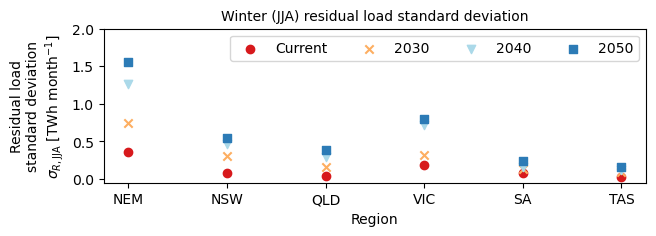

In [126]:
fig, ax = plt.subplots(1, 1, figsize=(7,2))

plot_std(
    ax,
    False,
    [shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50],
    ["Current", "2030", "2040", "2050"],
    [6, 7, 8],
    COLORS,
    "Residual load\nstandard deviation\n$\sigma_{R,\mathrm{JJA}}$ [TWh month$^{-1}$]",
    yticks=np.arange(0, 2.1, .5),
    legend_loc="upper right"
)

ax.set_title("Winter (JJA) residual load standard deviation", loc="center", fontsize=10)
ax.set_xlabel("Region")

plt.savefig("figures/residual_load_std_JJA.pdf", format="pdf", bbox_inches="tight")

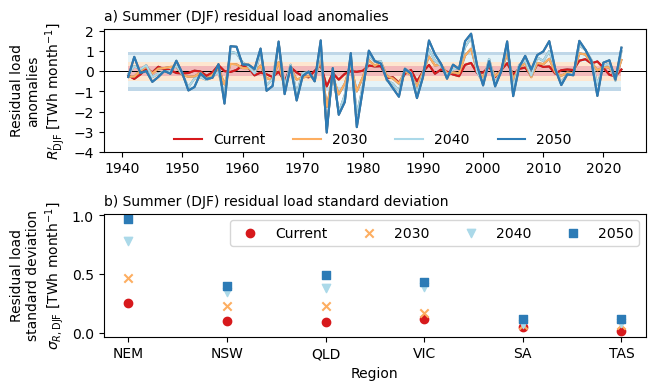

In [127]:
fig, ax = plt.subplots(2, 1, figsize=(7,4))

plot_ts(
    ax[0],
    [shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50],
    ["Current", "2030", "2040", "2050"],
    "NEM",
    [12, 1, 2],
    COLORS,
    True,
    # "Residual load anomalies\n[TWh month$^{-1}$],
    "Residual load\nanomalies\n$R^{\prime}_{\mathrm{DJF}}$ [TWh month$^{-1}$]",
    np.arange(-4, 2.1, 1),
    # "$\Delta$ residual load\n[$\sigma_{current}$ year$^{-1}$]",
    "upper right"
)
plot_std(
    ax[1],
    False,
    [shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50],
    ["Current", "2030", "2040", "2050"],
    [12, 1, 2],
    COLORS,
    "Residual load\nstandard deviation\n$\sigma_{R,\mathrm{DJF}}$ [TWh month$^{-1}$]",
    yticks=np.arange(0, 1.1, .5),
    legend_loc="upper right"
)

ax[0].set_title("a) Summer (DJF) residual load anomalies", loc="left", fontsize=10)
ax[1].set_title("b) Summer (DJF) residual load standard deviation", loc="left", fontsize=10)

ax[1].set_xlabel("Region")

plt.subplots_adjust(hspace=0.5)

plt.savefig("figures/residual_load_ts_std_DJF.pdf", format="pdf", bbox_inches="tight")

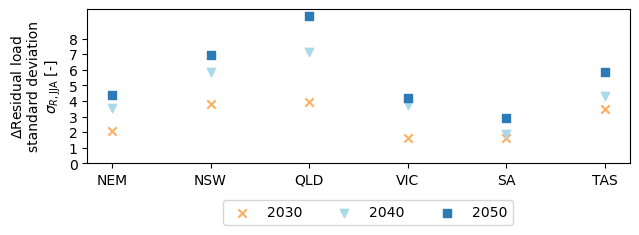

In [91]:
fig, ax = plt.subplots(figsize=(7,2))

plot_std(
    ax,
    True,
    [shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50],
    ["Current", "2030", "2040", "2050"],
    [6, 7, 8],
    COLORS,
    "$\Delta$Residual load\nstandard deviation\n$\sigma_{R,\mathrm{JJA}}$ [-]",
    yticks=np.arange(0, 8.1, 1),
    legend_loc=(0.25,-0.4)
)

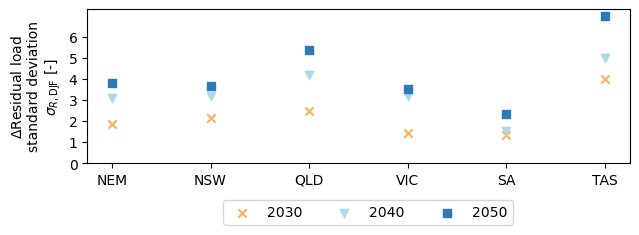

In [92]:
fig, ax = plt.subplots(figsize=(7,2))

plot_std(
    ax,
    True,
    [shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50],
    ["Current", "2030", "2040", "2050"],
    [12, 1, 2],
    COLORS,
    "$\Delta$Residual load\nstandard deviation\n$\sigma_{R,\mathrm{DJF}}$ [-]",
    yticks=np.arange(0, 6.1, 1),
    legend_loc=(0.25,-0.4)
)

## Correlation between modes and shortfall for each month

In [44]:
def correlate_modes_months(energy_ds, mode_ds):
    """
    Return 2d array of spearman correlations between each region in energy_ds and mode_ds
    
    energy_ds, mode_ds: arrays of energy variable and mode of variability
    """
    def _subset_ds(ds1, ds2):
        if len(ds1.time.values) > len(ds2.time.values):
            return ds1.sel(time=ds2.time.values), ds2
        elif len(ds1.time.values) < len(ds2.time.values):
            return ds1, ds2.sel(time=ds1.time.values)
        else:
            raise ValueError("Problem with function")
            
    cor_list = []
    pval_list = []
    for month in range(1, 13):
        # Drop NaNs (DMI and Nino34 have them at start of time series)
        _m_mode = mode_ds.dropna("time")
        _m_energy = energy_ds.where(mode_ds.notnull(), drop=True)
        
        _m_mode = fn.sel_month(_m_mode, month)
        _m_energy = fn.sel_month(_m_energy, month)
                
        if len(_m_mode.time.values) != len(_m_energy.time.values):
            _m_mode, _m_energy = _subset_ds(_m_mode, _m_energy)

        _m_cor, _m_pval = fn.xr_spearmanr(_m_mode, _m_energy)
        
        _m_cor = _m_cor.expand_dims({"month": [month]})
        _m_pval = _m_pval.expand_dims({"month": [month]})
        
        cor_list.append(_m_cor)
        pval_list.append(_m_pval)
        
    mode_cor_month = xr.concat(cor_list, dim="month")
    mode_pval_month = xr.concat(pval_list, dim="month")
    
    return mode_cor_month, mode_pval_month

In [45]:
def get_monthly_cor_for_region(cor_dict):
    """
    Concat monthly correlations over all modes
    
    cor_dict: dict of correlation values
    """
    mode_names = list(cor_dict.keys())
    
    da_list = [
        cor_dict[i].expand_dims({"mode": [i]})
        for i in mode_names
    ]
    return xr.concat(da_list, dim="mode")

In [46]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    energy_mode_cor = {}
    energy_mode_pval = {}
    for sh, scenario in zip(
        [
            wind_current, wind_SC30, wind_SC40, wind_SC50,
                        
            solar_current, solar_SC30, solar_SC40, solar_SC50,
            
            wind_current + solar_current, wind_SC30 + solar_SC30, wind_SC40 + solar_SC40, wind_SC50 + solar_SC50,
                        
            demand_current, demand_SC30, demand_SC40, demand_SC50,
            
            shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50,
        ],
        [
            "wind_current", "wind_SC30", "wind_SC40", "wind_SC50",
            "solar_current", "solar_SC30", "solar_SC40", "solar_SC50",
            "gen_current", "gen_SC30", "gen_SC40", "gen_SC50",
            "demand_current", "demand_SC30", "demand_SC40", "demand_SC50",
            "shortfall_current", "shortfall_SC30", "shortfall_SC40", "shortfall_SC50",
        ]
    ):
        
        mode_cor = {}
        mode_pval = {}
        for mode_ds, name in zip(
            [nino34, dmi, sam],
            ["ENSO", "IOD", "SAM"]
        ):
            mode_cor[name], mode_pval[name] = correlate_modes_months(sh, mode_ds)
        energy_mode_cor[scenario] = get_monthly_cor_for_region(mode_cor)
        energy_mode_pval[scenario] = get_monthly_cor_for_region(mode_pval)

In [48]:
def plot_mode_cor(scenario="current", savefig=False, filename=None):
    """
    Panel plot correlation between modes and demand, wind, solar and wind + solar
    
    scenario: str, 'current', 'SC30', 'SC40' or 'SC50'
    savefig: bool, whether to save figure or not
    filename: str, filename for saved figure
    """                 
    plot_letters = np.array(letters[:24]).reshape((6,4))

    fig, ax = plt.subplots(5, 4, figsize=(7,2.9))

    plot_list = []

    for i, r in enumerate(energy_mode_cor["demand_current"].region.values[1:]):

        # cor_list = []

        for j, (s, s_name) in enumerate(
            zip(
                ["demand_", "wind_", "solar_", "shortfall_"],
                ["Demand", "Wind", "Solar", "Residual load"]
            )):

            d = energy_mode_cor[s + scenario].sel(region=r)

            # Significance using False Discovery Rate alpha=0.1
            pval = fn.fdr(
                energy_mode_pval[s + scenario].sel(region=r), alpha=0.1
            )

            d_plot = d.values
            cmap = "PiYG"
            vmax = 0.5
            extend="neither"
            print(np.max([np.max(d_plot), np.abs(np.min(d_plot))]))

            p = ax[i,j].pcolormesh(d_plot, cmap=cmap, vmin=-vmax, vmax=vmax)
            plot_list.append(p)

            if (r != "TAS") & (s_name != "solar_"):
                for x in range(pval.shape[0]):
                    for y in range(pval.shape[1]):
                        if pval[x,y]:
                            ax[i,j].scatter(y+0.5, x+0.5, c="k", s=10, ec="white", lw=0.5)

            ax[i,j].set_xticks([])

            ax[i,j].invert_yaxis() 
            ax[i,j].set_yticks([])

            ax[-1,j].set_xticks(np.arange(0.5, 12, 1))
            ax[-1,j].set_xticklabels(["J", "", "M", "", "M", "", "J", "", "S", "", "N", ""])
            ax[-1,j].set_xlabel("Month")

            ax[0,j].set_title(s_name, fontsize=10)

            if (i == 4) & (j == 2):
                pass
            elif (i == 4) & (j == 3):
                pass
            else:
                ax[i,j].text(0.5, -0.5, plot_letters[i,j], fontsize=8, va="center", ha="center")

        print()

        ax[i,0].set_yticks([0.5, 1.5, 2.5])
        ax[i,0].set_yticklabels(energy_mode_cor["shortfall_current"].mode.values)

        ax[i,0].text(-0.45, 0.5, r, rotation=90, transform=ax[i,0].transAxes, va="center", ha="center")

    plt.subplots_adjust(hspace=0.4, wspace=0.06)

    cax = fig.add_axes([0.145, -0.09, 0.15, 0.015])
    cbar = fig.colorbar(plot_list[0], cax=cax, ticks=[-0.5, 0, 0.5], orientation="horizontal")
    cbar.ax.set_xlabel(r"Spearman $\rho$ [-]")

    ax[-1,-2].axis('off')
    ax[-1,-1].text(0.5, -0.5, 's', fontsize=8, va="center", ha="center")

    ax[-2,-2].set_xticks(np.arange(0.5, 12, 1))
    ax[-2,-2].set_xticklabels(["J", "", "M", "", "M", "", "J", "", "S", "", "N", ""])
    ax[-2,-2].set_xlabel("Month")
    
    if savefig:
        plt.savefig("figures/" + filename + ".pdf", format="pdf", bbox_inches="tight")

0.3153520003358381
0.3543931824860417
0.38319130179253597
0.3640905083749632

0.3626422064564879
0.28256580328281766
0.40680492002854624
0.3009319507997145

0.31948700726249946
0.3195499769111288
0.44305444775618147
0.2829646110574703

0.29052096889299356
0.31992779480290495
0.4067629402627933
0.3742076319214138

0.27018177238571006
0.4139624700894169
nan
0.4186012342051131



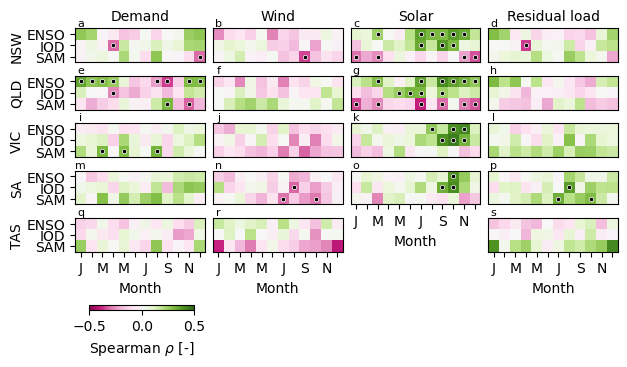

In [83]:
plot_mode_cor(scenario="current", savefig=True, filename="correlation_mode_demand_gen_states")

In [57]:
def plot_mode_cor_diff(var, savefig=False, filename=None):
    """
    Panel plot correlation and difference in correlation
    
    var: str, variable e.g. 'shortfall'
    savefig: bool, whether to save figure or not
    filename: str, filename for saved figure
    """
    def _plot_sign(axis, d1, d2, baseline=None, v1="month", v2="mode"):
        """
        Plot marker if sign change between d1 and d2, given baseline condition.
        
        d1, d2: datasets
        baseline: dataset used to threshold sign changes, default None
        v1, v2: str, dim names
        """
        sign = np.sign(d2) - np.sign(d1) # sign change
        for x, r in enumerate(sign[v1]):
            for y, r2 in enumerate(sign[v2]):
                if sign.sel({v1: r, v2: r2}).values != 0:
                    if baseline is None: # if no baseline, mark every case of sign change
                        axis.scatter(x+0.5, y+0.5, c="k", s=10, ec="white", lw=0, zorder=0.5, marker="^")
                    else:
                        baseline_val = baseline.sel({v1: r, v2: r2}).values
                        if np.abs(baseline_val) > 0.2: # if sign change for baseline value, |v|<0.1, don't mark
                            axis.scatter(x+0.5, y+0.5, c="k", s=10, ec="white", lw=1, marker="^")
                        else:
                            pass
                        
    plot_letters = np.array(letters[:24]).reshape((6,4))

    fig, ax = plt.subplots(5, 4, figsize=(7,2.9))

    plot_list = []

    for i, r in enumerate(energy_mode_cor[var + "_current"].region.values[1:]):

        cor_list = []

        for j, (s, s_name) in enumerate(
            zip(
                ["_current", "_SC30", "_SC40", "_SC50"],
                ["Current", "2030 - current", "2040 - 2030", "2050 - 2040"]
            )):

            d = energy_mode_cor[var + s].sel(region=r)
            cor_list.append(d)

            # Significance using False Discovery Rate alpha=0.1
            pval = fn.fdr(
                energy_mode_pval[var + s].sel(region=r), alpha=0.1
            )

            # First column correlation, subsequent columns are diff of d and previous column
            if s == "_current":
                d_plot = d.values
                cmap = "PiYG"
                vmax = 0.4
                extend="neither"
            else:
                d_plot = cor_list[j].values - cor_list[j-1].values
                cmap = "RdBu"
                vmax = 0.3
                extend="both"
            print(np.max([np.max(d_plot), np.abs(np.min(d_plot))]))

            p = ax[i,j].pcolormesh(d_plot, cmap=cmap, vmin=-vmax, vmax=vmax)
            plot_list.append(p)

            if s == "_current":
                for x in range(pval.shape[0]):
                    for y in range(pval.shape[1]):
                        if pval[x,y]:
                            ax[i,j].scatter(y+0.5, x+0.5, c="k", s=10, ec="white", lw=0.5)
            
            ax[i,j].set_xticks([])

            ax[i,j].invert_yaxis() 
            ax[i,j].set_yticks([])

            ax[-1,j].set_xticks(np.arange(0.5, 12, 1))
            ax[-1,j].set_xticklabels(["J", "", "M", "", "M", "", "J", "", "S", "", "N", ""])
            ax[-1,j].set_xlabel("Month")

            ax[0,j].set_title(s_name, fontsize=10)

            ax[i,j].text(0.5, -0.5, plot_letters[i,j], fontsize=8, va="center", ha="center")

        print()

        ax[i,0].set_yticks([0.5, 1.5, 2.5])
        ax[i,0].set_yticklabels(energy_mode_cor["shortfall_current"].mode.values)

        ax[i,0].text(-0.45, 0.5, r, rotation=90, transform=ax[i,0].transAxes, va="center", ha="center")

    plt.subplots_adjust(hspace=0.4, wspace=0.06)

    cax = fig.add_axes([0.145, -0.09, 0.15, 0.015])
    cbar = fig.colorbar(plot_list[0], cax=cax, ticks=[-0.4, 0, 0.4], orientation="horizontal")
    cbar.ax.set_xlabel(r"Spearman $\rho$ [-]")

    cax2 = fig.add_axes([0.44, -0.09, 0.15, 0.015])
    cbar2 = fig.colorbar(plot_list[-1], cax=cax2, ticks=[-0.3, 0, 0.3], orientation="horizontal", extend="neither")
    cbar2.ax.set_xlabel(r"Spearman $\rho$ difference [-]")
    
    if savefig:
        plt.savefig("figures/" + filename + ".pdf", format="pdf", bbox_inches="tight")

0.3640905083749632
0.25842743797489603
0.09586079509676335
0.056252886108895506

0.3009319507997145
0.2524033415893539
0.11240082280340877
0.10201083077956424

0.2829646110574703
0.06966542126694933
0.11428991226228956
0.031148986188657107

0.3742076319214138
0.07436715503127493
0.014000251878594508
0.05784811720750602

0.4186012342051131
0.08962679988245666
0.01761051173334452
0.013643423869694804



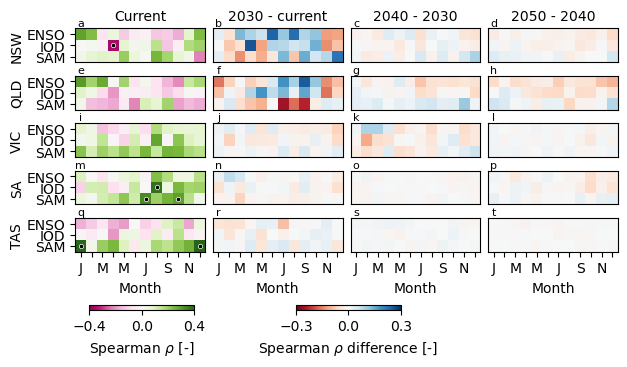

In [111]:
plot_mode_cor_diff("shortfall", savefig=True, filename="correlation_mode_residload_states")

### Combine above figures for NEM

In [129]:
def plot_mode_cor_NEM(savefig=False, filename=None):
    """
    Panel plot correlation between modes and demand, wind, solar, wind + solar and residual load,
    and changes for residual load with scenario. NEM only.
    
    savefig: bool, whether to save figure or not
    filename: str, filename for saved figure
    """                 
    plot_letters = np.array(letters[:24]).reshape((6,4))

    fig, ax = plt.subplots(2, 4, figsize=(7,2))

    ############### Correlation with demand, gen
    plot_list = []

    i = 0
    r = "NEM"
    
    cor_list = []

    for j, (s, s_name) in enumerate(
        zip(
            ["demand_", "wind_", "solar_", "gen_"],
            ["Demand\nCurrent", "Wind\nCurrent", "Solar\nCurrent", "Wind + solar\nCurrent"]
        )):

        d = energy_mode_cor[s + "current"].sel(region=r)
        cor_list.append(d)

        # Significance using False Discovery Rate alpha=0.1
        pval = fn.fdr(
            energy_mode_pval[s + "current"].sel(region=r), alpha=0.1
        )

        d_plot = d.values
        cmap = "PiYG"
        vmax = 0.5
        extend="neither"
        print(np.max([np.max(d_plot), np.abs(np.min(d_plot))]))

        p = ax[i,j].pcolormesh(d_plot, cmap=cmap, vmin=-vmax, vmax=vmax)
        plot_list.append(p)

        for x in range(pval.shape[0]):
            for y in range(pval.shape[1]):
                if pval[x,y]:
                    ax[i,j].scatter(y+0.5, x+0.5, c="k", s=10, ec="white", lw=0.5)

        ax[i,j].set_xticks([])

        ax[i,j].invert_yaxis() 
        ax[i,j].set_yticks([])

        ax[i,j].set_xticks(np.arange(0.5, 12, 1))
        ax[i,j].set_xticklabels(["J", "", "M", "", "M", "", "J", "", "S", "", "N", ""])
        # ax[i,j].set_xlabel("Month")

        ax[0,j].set_title(plot_letters[i,j] + ") " + s_name, fontsize=10, loc="center")

        # ax[i,j].text(0.5, -0.5, plot_letters[i,j], fontsize=8, va="center", ha="center")

    print()

    ax[i,0].set_yticks([0.5, 1.5, 2.5])
    ax[i,0].set_yticklabels(energy_mode_cor["shortfall_current"].mode.values)
        
    ############### Correlation with resid load
    i = 1
    var = "shortfall"
    cor_list = []

    for j, (s, s_name) in enumerate(
        zip(
            ["_current", "_SC30", "_SC40", "_SC50"],
            ["Residual load\nCurrent", "Residual load\n2030 - current", "Residual load\n2040 - 2030", "Residual load\n2050 - 2040"]
        )):

        d = energy_mode_cor[var + s].sel(region=r)
        cor_list.append(d)

        # Significance using False Discovery Rate alpha=0.1
        pval = fdr(
            energy_mode_pval[var + s].sel(region=r), alpha=0.1
        )

        # First column correlation, subsequent columns are diff of d and previous column
        if s == "_current":
            d_plot = d.values
            cmap = "PiYG"
            vmax = 0.4
            extend="neither"
        else:
            d_plot = cor_list[j].values - cor_list[j-1].values
            cmap = "RdBu"
            vmax = 0.2
            extend="both"
        print(np.max([np.max(d_plot), np.abs(np.min(d_plot))]))

        p = ax[i,j].pcolormesh(d_plot, cmap=cmap, vmin=-vmax, vmax=vmax)
        plot_list.append(p)

        if s == "_current":
            for x in range(pval.shape[0]):
                for y in range(pval.shape[1]):
                    if pval[x,y]:
                        ax[i,j].scatter(y+0.5, x+0.5, c="k", s=10, ec="white", lw=0.5)

        # if s_name != "_current":
        #     _plot_sign(ax[i,j], cor_list[j-1], cor_list[j], baseline=cor_list[0])

        ax[i,j].set_xticks([])

        ax[i,j].invert_yaxis() 
        ax[i,j].set_yticks([])

        ax[-1,j].set_xticks(np.arange(0.5, 12, 1))
        ax[-1,j].set_xticklabels(["J", "", "M", "", "M", "", "J", "", "S", "", "N", ""])
        ax[-1,j].set_xlabel("Month")

        ax[1,j].set_title(plot_letters[i,j] + ") " + s_name, fontsize=10, loc="center")

        # ax[i,j].text(0.5, -0.5, plot_letters[i,j], fontsize=8, va="center", ha="center")

    print()

    ax[i,0].set_yticks([0.5, 1.5, 2.5])
    ax[i,0].set_yticklabels(energy_mode_cor["shortfall_current"].mode.values)

    # ax[i,0].text(-0.45, 0.5, r, rotation=90, transform=ax[i,0].transAxes, va="center", ha="center")

    plt.subplots_adjust(hspace=2.2, wspace=0.06)

    cax = fig.add_axes([0.145, -0.18, 0.15, 0.03])
    cbar = fig.colorbar(plot_list[0], cax=cax, ticks=[-0.5, 0, 0.5], orientation="horizontal")
    cbar.ax.set_xlabel(r"Spearman $\rho$ [-]")
    
    cax2 = fig.add_axes([0.54, -0.18, 0.15, 0.03])
    cbar2 = fig.colorbar(plot_list[-1], cax=cax2, ticks=[-0.2, 0, 0.2], orientation="horizontal", extend="neither")
    cbar2.ax.set_xlabel(r"Spearman $\rho$ difference [-]")
    
    if savefig:
        plt.savefig("figures/" + filename + ".pdf", format="pdf", bbox_inches="tight")

0.33178707862810125
0.31178372024684103
0.40953360480248513
0.3193610679652407

0.2651022207296083
0.13878510557911086
0.07833424289492462
0.07489190210318626



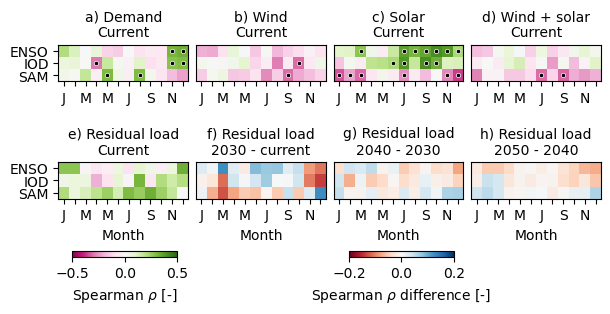

In [130]:
plot_mode_cor_NEM(True, "correlation_mode_NEM")

In [58]:
for k,v in energy_mode_cor.items():
    print(k)
    print(v.sel(region="NEM").min().values, v.sel(region="NEM").max().values)
    print()

wind_current
-0.31178372024684103 0.09806473279879098

wind_SC30
-0.3103983879769951 0.1333487259141094

wind_SC40
-0.33510348012258084 0.11941144368414422

wind_SC50
-0.31780781663238317 0.12203517904370093

solar_current
-0.3646362453297511 0.40953360480248513

solar_SC30
-0.37108013937282225 0.4011586415347802

solar_SC40
-0.35859115906133243 0.4248352294194198

solar_SC50
-0.3512447000545737 0.4113387347298602

gen_current
-0.3193610679652407 0.13425129087779689

gen_SC30
-0.3208513496494689 0.10541119180554973

gen_SC40
-0.35325972881071316 0.14871332017967337

gen_SC50
-0.3483690861004995 0.1834095965744511

demand_current
-0.2957054699634776 0.33178707862810125

demand_SC30
-0.2957054699634776 0.33178707862810125

demand_SC40
-0.2957054699634776 0.33178707862810125

demand_SC50
-0.2957054699634776 0.33178707862810125

shortfall_current
-0.16607195331850044 0.2651022207296083

shortfall_SC30
-0.1270517610511733 0.31163679106670583

shortfall_SC40
-0.17860291339574322 0.3474245413

# Energy during climate driver phases

In [49]:
def sel_on_mode(ds, mode_ds, phase, sd_divisor=1):
    """
    Return array of ds below, between or above thresholds of climate mode.
    Uses mean +/- standard deviation/x as threshold.
    
    ds: array to select on
    mode_ds: array of climate mode index
    phase: str, "neutral", "positive" or "negative"
    ds_divisor: float, divisor of standard deviation used to determine negative/neutral/positive
    """
    if phase == "negative":
        return ds.where(mode_ds < mode_ds.mean("time") - mode_ds.std("time") / sd_divisor, drop=True)#.dropna("time")
    elif phase == "positive":
        return ds.where(mode_ds > mode_ds.mean("time") + mode_ds.std("time") / sd_divisor, drop=True)#.dropna("time")
    elif phase == "neutral":
        return ds.where(
            (mode_ds >= mode_ds.mean("time") - mode_ds.std("time") / sd_divisor) &
            (mode_ds <= mode_ds.mean("time") + mode_ds.std("time") / sd_divisor),
            drop=True
        )#.dropna("time")
    else:
        raise ValueError("Incorrect 'phase'.")

In [50]:
def get_violin_data(ds, mode_list):
    """
    Return list of lists of ds subset on negative, neutral and positive phases
    of three climate modes
    
    ds: array to subset
    mode_list: list, datasets of climate modes to subset on
    """
    L = []
    for mode in mode_list:
        for phase in ["negative", "neutral", "positive"]:
            subset = sel_on_mode(ds, mode, phase)
            L.append(list(subset.values))
    return L

In [51]:
def plot_violin(ax, ds_list, mode_ds_list, labels, colors=["tab:blue", "tab:orange", "tab:green"], x_offsets = [-0.2, 0, 0.2]):
    """
    Violin plot for each list in data_list
    
    ax: axis to plot onto
    ds_list: list, containing datasets to plot
    mode_ds_list: list of length 3, containing datasets of climate mode indices
    labels: list, labels of data
    colors: list, colors to plot. For 2 data sets, will exclude the middle one.
    x_offsets: list, spacing between data sets on x-axis. For 2 data sets, will exclude the middle one.
    """
    legend_items = []
    def _add_label(violin, label):
        color = violin["bodies"][0].get_facecolor().flatten()
        legend_items.append((mpatches.Patch(color=color), label))
        
    # If only 2 datasets to plot, remove the middle color and x_offset
    if len(ds_list) == 2:
        colors = [colors[0], colors[-1]]
        x_offsets = [x_offsets[0], x_offsets[-1]]
    # If only 1 dataset to plot, only keep the first color and middle x_offset
    if len(ds_list) == 1:
        colors = [colors[0]]
        x_offsets = [x_offsets[1]]
        
    # Get data for plotting
    data_list = [get_violin_data(d, mode_ds_list) for d in ds_list]
    
    # Plot
    for i, (data, label, color, offset) in enumerate(zip(
        data_list, labels, colors, x_offsets
    )):
        if len(data[0]) == 0:
            pass
        else:
            n = [len(data[N]) for N in range(9)]
            print(n)
            
            # Distribution tests
            for j in [0, 3, 6]:
                ks_p = ks_2samp(data[j], data[j+2])[1]
                ad_p = anderson_ksamp([data[j], data[j+2]])[-1]
                print(ks_p < 0.05)
                print(ad_p < 0.05)
            
            vp = ax.violinplot(
                data,
                positions=np.arange(1 + offset, 9.01 + offset, 1),
                widths=0.3,
                # quantiles=[[0.025, 0.5, 0.975] for _ in range(9)],
                quantiles=[[0.05, 0.5, 0.95] for _ in range(9)],
                showextrema=False,
                showmeans=False
            )

            # Set violin color
            for pc in vp['bodies']:
                pc.set_facecolor(color)
            vp["cquantiles"].set_edgecolor(color)
            # vp["cmins"].set_edgecolor(color)
            # vp["cmaxes"].set_edgecolor(color)
            # vp["cmeans"].set_edgecolor(color)
            # Add legend label manually
            _add_label(vp, label) 
            
    ax.set_xticks(range(1, 10))
    ax.set_xticklabels(["-", "n\nSAM", "+", "-", "n\nENSO", "+", "-", "n\nIOD", "+"])
    ax.set_xlim(0.5, 9.5)
    for x in np.arange(1.5, 9, 1):
        ax.axvline(x, c="lightgray")
    for x in np.arange(3.5, 9, 3):
        ax.axvline(x, c="k")

In [52]:
def _months_beside(month):
    arr = np.array([(month + i) % 12 for i in [-1, 0, 1]])
    arr[arr == 0] = 12
    return list(arr)

In [53]:
def _print_months(month_number):
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    if isinstance(month_number, list):
        m = [months[i - 1] for i in month_number]
        m2 = [i[0] for i in m]
        return "".join(m2)
    elif 1 <= month_number <= 12:
        return months[month_number - 1]
    elif month_number == 0: # special case for TAS solar
        return "None" 
    else:
        raise ValueError("Incorrect 'month_number'")

### How scenarios affect mode-energy relationships

In [55]:
def violin_scenario_mode(
    ax,
    energy_dict,
    energy_name,
    energy_units,
    mode_dict,
    energy_cor,
    region,
    normalise=True,
    period=None,
    months_beside=False,
    add_legend=True,
    legend_loc=(0.05, 0.05),
    savefig=False,
    filename=None
):
    """
    Plot energy variable subset by climate mode phase
    
    ax: axis to plot onto
    energy_dict: dict with keys as scenario names and values as datasets to plot
    energy_name: str, name of energy variable
    energy_units: str, units of energy variable
    mode_dict: dictionary with keys as mode names and vars as mode datasets
    energy_cor: dataset of month of max correlation between energy_ds and modes
    region: str, regions to select.
    normalise: bool, whether to normalise energy data
    period: slice, desired time period. Otherwise ignore.
    months_beside: bool, whether or not to include months either side of month of max correlation
    add_legend: bool, whether or not to add legend
    legend_loc: str of tuple
    savefig: bool, whether to save figure or not
    filename: str, filename for saved figure
    """
    legend_items = []
    def _add_label(violin, label):
        color = violin["bodies"][0].get_facecolor().flatten()
        legend_items.append((mpatches.Patch(color=color), label))
        
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    
    scen1, scen2, scen3, scen4 = energy_dict.keys()
    energy1, energy2, energy3, energy4 = energy_dict.values()
    
    mode1_name = list(mode_dict.keys())[0]
    mode1_ds = list(mode_dict.values())[0]
    
    if isinstance(period, slice):
        energy1 = energy1.sel(time=period)
        energy2 = energy2.sel(time=period)
        energy3 = energy3.sel(time=period)
        energy4 = energy4.sel(time=period)
        mode1_ds = mode1_ds.sel(time=period)
        
    energy1 = energy1.sel(region=region)
    energy2 = energy2.sel(region=region)
    energy3 = energy3.sel(region=region)
    energy4 = energy4.sel(region=region)
    
    if normalise:
        energy1 = fn.normalise(energy1)
        energy2 = fn.normalise(energy2)
        energy3 = fn.normalise(energy3)
        energy4 = fn.normalise(energy4)
        
    month1 = energy_cor.sel(mode=mode1_name, region=region).values
    
    if months_beside:
        # Get months either side
        month1 = _months_beside(month1)

    print(month1)
    energy1 = energy1.isel(time=energy1.time.dt.month.isin(month1))
    energy2 = energy2.isel(time=energy2.time.dt.month.isin(month1))
    energy3 = energy3.isel(time=energy3.time.dt.month.isin(month1))
    energy4 = energy4.isel(time=energy4.time.dt.month.isin(month1))
    
    pdata = []
    for i in range(3):
        for ds in [energy1, energy2, energy3, energy4]:
            _ds = get_violin_data(ds, [mode1_ds])[i]
            pdata.append(_ds)
            
    # Distribution tests
    ks_signif = []
    ad_signif = []
    for j in [0, 1, 2, 3]:
        ks_p = ks_2samp(pdata[j], pdata[j+8])[1]
        ad_p = anderson_ksamp([pdata[j], pdata[j+8]])[-1]
        ks_signif.append(ks_p < 0.05)
        ad_signif.append(ad_p < 0.05)
    print(ks_signif)
    print(ad_signif)
            
    labels = [scen1, scen2, scen3, scen4] * 4
    colors=COLORS * 4
    x_offsets = np.array([np.array([-0.3, 0, 0.3]) + k for k in range(4)]).T.reshape(-1)
    
    # Plot
    for i, (data, label, color, offset) in enumerate(zip(
        pdata, labels, colors, x_offsets
    )):
        print([len(j) for j in pdata])
                
        vp = ax.violinplot(
            data,
            positions=[offset],
            widths=0.3,
            # quantiles=[0.025, 0.5, 0.975],
            quantiles=[0.05, 0.5, 0.95],
            showextrema=False,
            showmeans=False
        )

        # Set violin color
        for pc in vp['bodies']:
            pc.set_facecolor(color)
        vp["cquantiles"].set_edgecolor(color)
        # Add legend label manually
        _add_label(vp, label) 
        
    t_labels = []
    for ks, ad in zip(ks_signif, ad_signif):
        if ks & ad:
            t_labels.append("B")
        elif ks & ~ad:
            t_labels.append("KS")
        elif ~ks & ad:
            t_labels.append("AD")
        else:
            t_labels.append("")
    print(t_labels)
    for x, t in zip([0.13, 0.375, 0.625, 0.875], t_labels):
        ax.text(x, 0.05, t, transform=ax.transAxes, ha="center")

    for x in [0.5, 1.5, 2.5]:
        ax.axvline(x, c="k", lw=0.5)
    ax.axhline(0, c="k", lw=0.5)

    ax.set_xticks(x_offsets)
    ax.set_xticklabels(np.array(["$-$", "n", "$+$"] * 4).reshape(4, 3).T.reshape(-1))
    ax.set_xlabel(mode1_name + " phase")
    ax.set_xlim(-0.5, 3.5)

    ax.set_ylabel(energy_name + "\n" + energy_units)
    
    if add_legend:
        # Manual legend   
        col1 = Line2D([0], [0], marker='', linestyle="-", color="tab:gray")
        col2 = Line2D([0], [0], marker='', linestyle="-", color="tab:orange")
        col3 = Line2D([0], [0], marker='', linestyle="-", color="tab:green")
        col4 = Line2D([0], [0], marker='', linestyle="-", color="tab:blue")

        ax.legend(
            [col1, col2, col3, col4],
            labels[:4],
            loc=legend_loc,
            ncol=2,
            frameon=True
        )
    
    if savefig:
        plt.savefig("figures/" + filename + ".pdf", format="pdf", bbox_inches="tight")

    return month1

In [56]:
def panel_violin_scenario_mode(
    energy_dict,
    energy_cor,
    region,
    ylabel="Residual load [TWh per month]",
    yticks=np.arange(-16, 16.1, 4),
    save_fig=False,
    months_beside=True
):
    """
    Panel of ENSO, IOD and SAM influence on energy

    energy_dict: dict of size 4 with keys as scenario names and values as dataArrays
    energy_cor: dataset of month of max correlation between energy_ds and modes
    region: str, regions to select.
    ylabel: str,
    yticks: list or array of yticks
    save_fig: bool, whether to save figure
    """
    fig, ax = plt.subplots(1, 3, figsize=(7,3))

    m1 = violin_scenario_mode(
        ax[0],
        energy_dict,
        "",
        "",
        {"ENSO": nino34},
        energy_cor,
        region,
        normalise=False,
        months_beside=months_beside,
        add_legend=False
    )
    
    m2 = violin_scenario_mode(
        ax[1],
        energy_dict,
        "",
        "",
        {"IOD": dmi},
        energy_cor,
        region,
        normalise=False,
        months_beside=months_beside,
        add_legend=False
    )
    
    m3 = violin_scenario_mode(
        ax[2],
        energy_dict,
        "",
        "",
        {"SAM": sam},
        energy_cor,
        region,
        normalise=False,
        months_beside=months_beside,
        add_legend=False
    )
    
    import calendar
    if months_beside:
        m1 = ''.join([calendar.month_name[i][0] for i in m1])
        m2 = ''.join([calendar.month_name[i][0] for i in m2])
        m3 = ''.join([calendar.month_name[i][0] for i in m3])
    else:
        m1 = calendar.month_name[m1]
        m2 = calendar.month_name[m2]
        m3 = calendar.month_name[m3]
    
    ax[0].set_ylabel(ylabel)
    ax[0].set_title("a) "+m1+" ENSO", fontsize=10, loc="left")
    ax[1].set_title("b) "+m2+" IOD", fontsize=10, loc="left")
    ax[2].set_title("c) "+m3+" SAM", fontsize=10, loc="left")

    for a in ax:
        a.set_yticks(yticks)
    
    ax[1].set_yticklabels("")
    ax[2].set_yticklabels("")
    
    for x, s in zip([0.13, 0.38, 0.634, 0.88], ["Current", "2030", "2040", "2050"]):
        ax[0].text(x, 0.95, s, transform=ax[0].transAxes, ha="center", fontsize=7)
        ax[1].text(x, 0.95, s, transform=ax[1].transAxes, ha="center", fontsize=7)
        ax[2].text(x, 0.95, s, transform=ax[2].transAxes, ha="center", fontsize=7)

    if save_fig:
        plt.savefig("figures/resid_load_vs_mode_phase.pdf", format="pdf", bbox_inches="tight")

In [57]:
def print_conditional_tail_stats(energy_ds, mode_ds, months, region='NEM', upp_q=0.9, low_q=0.1):
    """
    Print number of months abv/below quantiles for different mode phases
    """
    energy = fn.sel_month(energy_ds.sel(region=region), months)
    energy_high = energy.quantile(upp_q, 'time')
    energy_low = energy.quantile(low_q, 'time')
    print(np.round(energy_low.values, 2), np.round(energy_high.values, 2))

    mode = fn.sel_month(mode_ds.sel(time=slice('1941', None)), months)

    neg = sel_on_mode(energy, mode, 'negative')
    neut = sel_on_mode(energy, mode, 'neutral')
    pos = sel_on_mode(energy, mode, 'positive')

    print(
        'Number of low values during negative, neutral, positive: ',
        neg.where(neg < energy_low).count().values,
        neut.where(neut < energy_low).count().values,
        pos.where(pos < energy_low).count().values
    )
    print(
        'Number of high values during negative, neutral, positive: ',
        neg.where(neg > energy_high).count().values,
        neut.where(neut > energy_high).count().values,
        pos.where(pos > energy_high).count().values
    )

In [143]:
for (mode_name, mode, months) in zip(['ENSO', 'IOD', 'SAM'], [nino34, dmi, sam], [[11, 12, 1], [7, 8, 9], [8, 9, 10]]):
    print(mode_name)
    for (scen_name, scen) in zip(['Curr.', '2030', '2040', '2050'], [shortfall_current, shortfall_SC30, shortfall_SC40, shortfall_SC50]):
        print(scen_name)
        print_conditional_tail_stats(scen, mode, months)
        print()


ENSO
Curr.
8.82 10.71
Number of low values during negative, neutral, positive:  3 20 2
Number of high values during negative, neutral, positive:  2 18 5

2030
3.89 6.49
Number of low values during negative, neutral, positive:  4 20 1
Number of high values during negative, neutral, positive:  3 12 10

2040
-1.25 2.7
Number of low values during negative, neutral, positive:  4 19 2
Number of high values during negative, neutral, positive:  3 13 9

2050
-8.88 -4.17
Number of low values during negative, neutral, positive:  5 17 3
Number of high values during negative, neutral, positive:  4 10 11

IOD
Curr.
8.87 11.8
Number of low values during negative, neutral, positive:  4 17 4
Number of high values during negative, neutral, positive:  4 17 4

2030
3.4 7.43
Number of low values during negative, neutral, positive:  4 17 4
Number of high values during negative, neutral, positive:  3 19 3

2040
-1.56 4.7
Number of low values during negative, neutral, positive:  4 20 1
Number of high values d

[11, 12, 1]
[False, False, False, False]
[False, False, False, False]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]


/jobfs/172908273.gadi-pbs/ipykernel_3103581/2629477213.py:91: UserWarning: p-value capped: true value larger than 0.25
  ad_p = anderson_ksamp([pdata[j], pdata[j+8]])[-1]


[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
[56, 56, 56, 56, 133, 133, 133, 133, 60, 60, 60, 60]
['', '', '', '']
[7, 8, 9]


/jobfs/172908273.gadi-pbs/ipykernel_3103581/2629477213.py:91: UserWarning: p-value capped: true value larger than 0.25
  ad_p = anderson_ksamp([pdata[j], pdata[j+8]])[-1]


[False, False, False, False]
[False, False, False, False]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
[48, 48, 48, 48, 146, 146, 146, 146, 55, 55, 55, 55]
['', '', '', '']
[8, 9, 10]
[False, True, True, True]
[True, True, True, True]
[32, 32, 32, 32, 193, 193, 193, 193, 24, 24, 24, 24]
[32, 32, 32, 32, 193, 193, 193, 193, 24, 24, 24, 24]
[32, 32, 32, 32, 193, 193, 193, 193, 24, 24, 24, 24]
[32, 32, 32, 32, 193, 193, 193, 193, 24, 24, 24, 24]
[32, 32, 32, 32

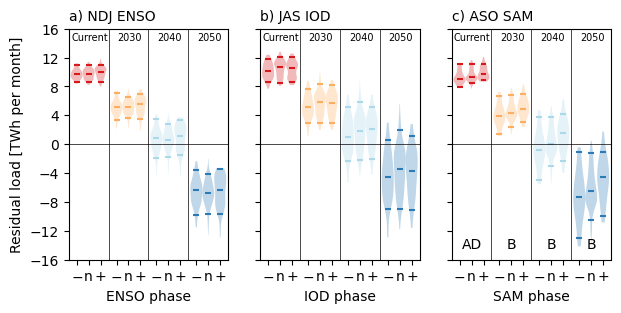

In [90]:
panel_violin_scenario_mode(
    {"Current": shortfall_current, "2030": shortfall_SC30, "2040": shortfall_SC40, "2050": shortfall_SC50},
    abs(energy_mode_cor["shortfall_current"]).idxmax("month").astype("int"),
    "NEM",
    save_fig=False
)

#### Add generation to REZs that have opposite relationship to climate modes

[8, 9, 10]
[True, True, False, False]
[True, True, False, False]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]


/jobfs/167748613.gadi-pbs/ipykernel_74051/1576749291.py:92: UserWarning: p-value floored: true value smaller than 0.001
  ad_p = anderson_ksamp([pdata[j], pdata[j+8]])[-1]
/jobfs/167748613.gadi-pbs/ipykernel_74051/1576749291.py:92: UserWarning: p-value capped: true value larger than 0.25
  ad_p = anderson_ksamp([pdata[j], pdata[j+8]])[-1]


[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
[40, 40, 40, 40, 172, 172, 172, 172, 37, 37, 37, 37]
['B', 'B', '', '']


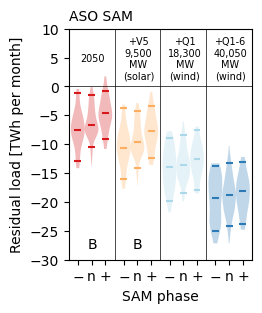

In [78]:
fig, ax = plt.subplots(1, 1, figsize=(7.1*(1/3),3))

violin_scenario_mode(
    ax,
    {
        "2050": shortfall_SC50,
        "2050+V5": shortfall_V5,
        "2050+Q1": shortfall_Q1,
        "2050+Q*": shortfall_Q1 + (shortfall_Q2 - shortfall_SC50) + (shortfall_Q5 - shortfall_SC50) + (shortfall_Q6 - shortfall_SC50)
    },
    "",
    "",
    {"SAM": sam},
    abs(energy_mode_cor["shortfall_current"]).idxmax("month").astype("int"),
    "NEM",
    normalise=False,
    months_beside=True,
    add_legend=False
)

ax.set_ylabel("Residual load [TWh per month]")
ax.set_title("ASO SAM", fontsize=10, loc="left")

ax.set_yticks(np.arange(-30, 10.1, 5))

for x, s in zip(
    [0.13, 0.38, 0.634, 0.88],
    ["2050", "+V5\n9,500\nMW\n(solar)", "+Q1\n18,300\nMW\n(wind)", "+Q1-6\n40,050\nMW\n(wind)"]
):
     ax.text(x, 0.87, s, transform=ax.transAxes, ha="center", fontsize=7, va="center")

plt.subplots_adjust(wspace=.3)
    
plt.savefig("figures/resid_load_vs_SAM_phase_additional_gen.pdf", format="pdf", bbox_inches="tight")

Overall standard deviation for all Decembers/Septembers for scenarios in figure above

In [146]:
for ds in [shortfall_SC50, shortfall_Q1, shortfall_T3, shortfall_N10]:
    print(fn.sel_month(ds.sel(region="NEM"), 1).std("time").values)

1.7149647783719555
2.4106980323053246
1.9193474258765677
1.7493467315689823


In [147]:
for ds in [shortfall_SC50, shortfall_V5, shortfall_Q1,
           shortfall_Q1 + (shortfall_Q2 - shortfall_SC50) + (shortfall_Q5 - shortfall_SC50) + (shortfall_Q6 - shortfall_SC50)
          ]:
    print(fn.sel_month(ds.sel(region="NEM"), 9).std("time").values)

2.401475280829053
2.4302600902637588
2.7733925929582264
3.143238272538709
